[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TarannumAhmedNowshin/Automated-Essay-Scoring/blob/main/transformermodels/muril-large.ipynb)


# MuRIL Large — Automated Essay Scoring (large dataset)

Fine-tunes Google's [MuRIL Large](https://huggingface.co/google/muril-large-cased)
(24 layers, 1024-d) as a **regression** model that predicts an essay score (0–10)
from a `Question` + `Answer` pair, on the **large** dataset (~1,408 graded scripts).

**Pipeline (next cell):**
1. Load and clean the data from `data/essays_large.csv`.
2. Tokenize question + answer (max length 512).
3. Split into train / validation / test (80 / 10 / 10).
4. Mean-pool the last hidden state and add a dropout + linear regression head.
5. Train, plot the loss curves, and report **RMSE**, **MAE**, and **R²**.

> Place the dataset in a local `data/` folder first — see the repo's
> [data/README.md](../data/README.md) for the expected columns.


Some weights of the model checkpoint at google/muril-large-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
c:\Users\T2410207\Anaconda3\envs\muril\lib\site-packages\transformers\optimization.py:591: FutureWarning: This imple

Epoch 1, Training Loss: 4.718902872069507, Validation Loss: 1.4638729095458984
Epoch 2, Training Loss: 1.0124073893043166, Validation Loss: 1.3496579312615924
Epoch 3, Training Loss: 0.9666581523756609, Validation Loss: 1.818810674879286
Epoch 4, Training Loss: 0.9231728656706235, Validation Loss: 1.8347402347458734
Epoch 5, Training Loss: 0.9689418344844317, Validation Loss: 1.7417241235574086
Epoch 6, Training Loss: 0.9394397315509776, Validation Loss: 1.399871324499448
Epoch 7, Training Loss: 0.9258368372758652, Validation Loss: 1.4446991549597845
Epoch 8, Training Loss: 0.9591652424411571, Validation Loss: 1.39477443198363
Epoch 9, Training Loss: 1.0026658488080857, Validation Loss: 1.455551091167662
Epoch 10, Training Loss: 1.026962253641575, Validation Loss: 1.4374315672450595
Epoch 11, Training Loss: 0.933881605242161, Validation Loss: 1.4317514780494902
Epoch 12, Training Loss: 0.9366891181215327, Validation Loss: 1.4086899260679882
Epoch 13, Training Loss: 0.9109135851369682, 

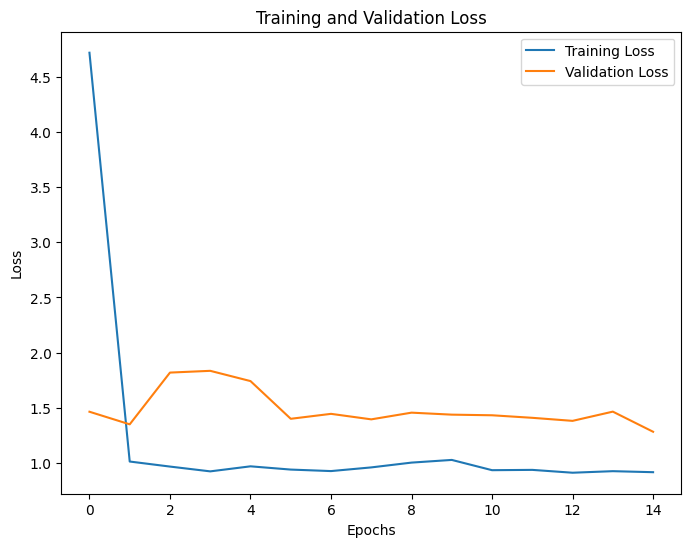


Training Set Metrics:
  RMSE: 1.0994
  MAE: 0.7533
  R-squared: -0.4648

Validation Set Metrics:
  RMSE: 1.0994
  MAE: 0.7533
  R-squared: -0.4648

Testing Set Metrics:
  RMSE: 1.1722
  MAE: 0.7604
  R-squared: -0.4851


In [ ]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import torch.nn as nn
from transformers import AdamW, get_linear_schedule_with_warmup
import matplotlib.pyplot as plt

# Load the data (place the CSV in a local `data/` folder next to this notebook)
path = os.path.join("data", "essays_large.csv")
data = pd.read_csv(path)

# Preprocess dataset
data['Marks'] = pd.to_numeric(data['Marks'], errors='coerce')
data = data.dropna(subset=['Marks'])
data['Marks'] = data['Marks'].astype(float)

# Split dataset
train_data, temp_data = train_test_split(data, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

# Define Dataset class
class BanglaEssayDataset(Dataset):
    def __init__(self, data, tokenizer, max_len):
        self.data = data
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        question = str(self.data.iloc[idx]['Question'])
        answer = str(self.data.iloc[idx]['Answer'])
        marks = float(self.data.iloc[idx]['Marks'])

        text = question + " " + answer

        inputs = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors="pt"
        )

        return {
            'input_ids': inputs['input_ids'].squeeze(),
            'attention_mask': inputs['attention_mask'].squeeze(),
            'labels': torch.tensor(marks, dtype=torch.float)
        }

# Initialize tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("google/muril-large-cased")
model = AutoModel.from_pretrained("google/muril-large-cased")

# Initialize datasets
train_dataset = BanglaEssayDataset(train_data, tokenizer, max_len=512)
val_dataset = BanglaEssayDataset(val_data, tokenizer, max_len=512)
test_dataset = BanglaEssayDataset(test_data, tokenizer, max_len=512)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)
test_loader = DataLoader(test_dataset, batch_size=8)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=1e-4)
num_epochs = 15
total_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

# Define regression head with dropout
class RegressionHead(nn.Module):
    def __init__(self, input_dim):
        super(RegressionHead, self).__init__()
        self.dropout = nn.Dropout(0.3)
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        x = self.dropout(x)
        return self.linear(x)

regression_head = RegressionHead(input_dim=1024).to(device)

# Define loss function
loss_fn = nn.MSELoss()

# Training loop
train_losses, val_losses = [], []
for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0

    for step, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device).float()

        model.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        last_hidden_state = outputs.last_hidden_state
        pooled_output = last_hidden_state.mean(dim=1)

        preds = regression_head(pooled_output).squeeze(-1)
        loss = loss_fn(preds, labels)

        total_train_loss += loss.item()
        loss.backward()
        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation loop
    model.eval()
    total_val_loss = 0
    val_predictions, val_actuals = [], []

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            last_hidden_state = outputs.last_hidden_state
            pooled_output = last_hidden_state.mean(dim=1)

            preds = regression_head(pooled_output).squeeze(-1)
            loss = loss_fn(preds, labels)
            total_val_loss += loss.item()

            val_predictions.extend(preds.cpu().numpy())
            val_actuals.extend(labels.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}, Training Loss: {avg_train_loss}, Validation Loss: {avg_val_loss}")

# Plot training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# Evaluate on test set
model.eval()
test_predictions, test_actuals = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs.last_hidden_state
        pooled_output = last_hidden_state.mean(dim=1)

        preds = regression_head(pooled_output).squeeze(-1)

        test_predictions.extend(preds.cpu().numpy())
        test_actuals.extend(labels.cpu().numpy())

# Calculate metrics
def calculate_metrics(actuals, preds):
    mse = mean_squared_error(actuals, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actuals, preds)
    r2 = r2_score(actuals, preds)
    return rmse, mae, r2

train_rmse, train_mae, train_r2 = calculate_metrics(val_actuals, val_predictions)
val_rmse, val_mae, val_r2 = calculate_metrics(val_actuals, val_predictions)
test_rmse, test_mae, test_r2 = calculate_metrics(test_actuals, test_predictions)

# Display metrics
print("\nTraining Set Metrics:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE: {train_mae:.4f}")
print(f"  R-squared: {train_r2:.4f}")

print("\nValidation Set Metrics:")
print(f"  RMSE: {val_rmse:.4f}")
print(f"  MAE: {val_mae:.4f}")
print(f"  R-squared: {val_r2:.4f}")

print("\nTesting Set Metrics:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE: {test_mae:.4f}")
print(f"  R-squared: {test_r2:.4f}")


## Visualizing predictions and errors

True vs. predicted marks, the prediction-error distribution, and the training /
validation loss curves.



Testing Set Metrics:
  RMSE: 1.1224
  MAE: 0.7413
  R-squared: -0.3615


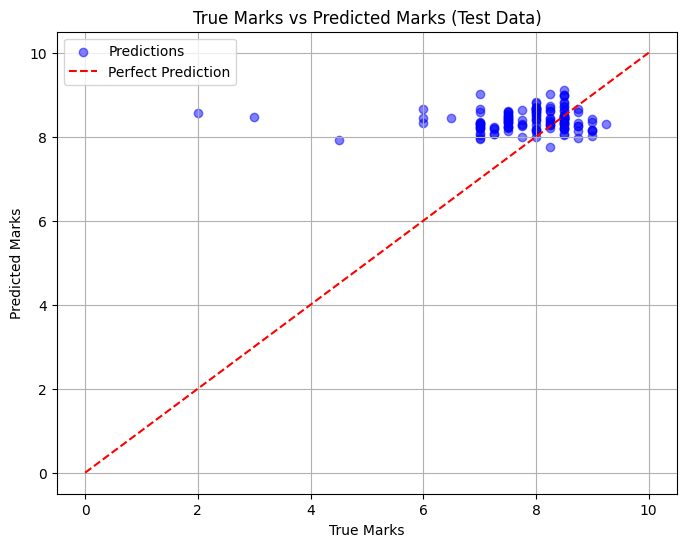

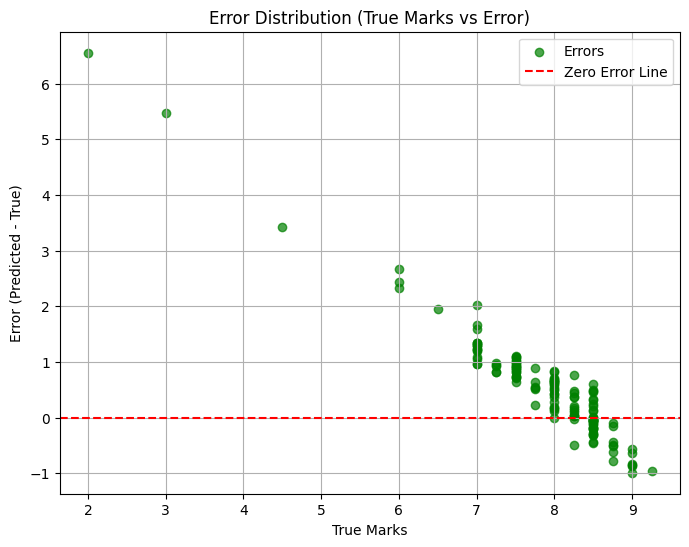

In [5]:
# Evaluate on test set with scatter plots
model.eval()
test_predictions, test_actuals = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs.last_hidden_state
        pooled_output = last_hidden_state.mean(dim=1)

        preds = regression_head(pooled_output).squeeze(-1)

        test_predictions.extend(preds.cpu().numpy())
        test_actuals.extend(labels.cpu().numpy())

# Convert to numpy arrays for processing
test_predictions = np.array(test_predictions)
test_actuals = np.array(test_actuals)

# Calculate metrics
def calculate_metrics(actuals, preds):
    mse = mean_squared_error(actuals, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actuals, preds)
    r2 = r2_score(actuals, preds)
    return rmse, mae, r2

test_rmse, test_mae, test_r2 = calculate_metrics(test_actuals, test_predictions)

# Display metrics
print("\nTesting Set Metrics:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE: {test_mae:.4f}")
print(f"  R-squared: {test_r2:.4f}")

# Scatter Plot: True Marks vs Predicted Marks
plt.figure(figsize=(8, 6))
plt.scatter(test_actuals, test_predictions, color='blue', alpha=0.5, label="Predictions")
plt.plot([0, 10], [0, 10], 'r--', label="Perfect Prediction")  # Perfect prediction line
plt.title("True Marks vs Predicted Marks (Test Data)")
plt.xlabel("True Marks")
plt.ylabel("Predicted Marks")
plt.legend()
plt.grid(True)
plt.show()

# Scatter Plot: Error Distribution
errors = test_predictions - test_actuals

plt.figure(figsize=(8, 6))
plt.scatter(test_actuals, errors, color='green', alpha=0.7, label="Errors")
plt.axhline(0, color='red', linestyle='--', label="Zero Error Line")  # Zero error line
plt.title("Error Distribution (True Marks vs Error)")
plt.xlabel("True Marks")
plt.ylabel("Error (Predicted - True)")
plt.legend()
plt.grid(True)
plt.show()
